# Introducción a la Ciencia de Datos: Tarea 2

Este notebook contiene el código de base para realizar la Tarea 2 del curso. Puede copiarlo en su propio repositorio y trabajar sobre el mismo.
Las **instrucciones para ejecutar el notebook** están en la [página inicial del repositorio](https://gitlab.fing.edu.uy/maestria-cdaa/intro-cd/).

**Se espera que no sea necesario revisar el código para corregir la tarea**, ya que todos los resultados y análisis relevantes deberían estar en el **informe en formato PDF**.


## Cargar bibliotecas (dependencias)
Recuerde instalar los requerimientos (`requirements.txt`) en el mismo entorno donde está ejecutando este notebook (ver [README](https://gitlab.fing.edu.uy/maestria-cdaa/intro-cd/)). Para la entrega 2 hay nuevas dependencias, por lo que es importante correr la siguiente celda.

In [ ]:
!pip install -r requirements.txt

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [ ]:
import re
import os

from time import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
import nltk
import matplotlib.patches as mpatches


from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.decomposition import PCA
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# ── core
import re, string, os, warnings, math, itertools
from pathlib import Path
from time import time

# ── stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD          # PCA for sparse data
from sklearn.metrics import ConfusionMatrixDisplay

# ── aesthetics
plt.style.use("ggplot")
sns.set_context("talk")
warnings.filterwarnings("ignore")

## Lectura de Datos

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# DataFrame con todos los discursos:
DATA_PATH = "/content/drive/MyDrive/IntroCD/Tarea1-IntroCD/us_2020_election_speeches.csv"


df_raw = pd.read_csv(DATA_PATH, parse_dates=["date"], dtype={"speaker": "category"})
#df_speeches = pd.read_csv('/content/drive/MyDrive/IntroCD/Tarea1-IntroCD/us_2020_election_speeches.csv')
print(f"Rows total: {len(df_raw):,}")
df_raw.head(2)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Rows total: 269


,speaker,title,text,date,location,type
0,David Perdue,Georgia Sen. David Perdue Speech Transcript at...,David Perdue: (00:01)\nHow great is it to be b...,2020-10-16,"Macon, Georgia",Campaign Speech
1,Joe Biden,"Joe Biden Southfield, MI Speech on Health Care...","Joe Biden: (00:00)\nHello, Michigan. Hi, how a...",2020-10-16,"Southfield ,Michigan",Campaign Speech


In [ ]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CONFIGURACIÓN GLOBAL DE STOP-WORDS Y HELPERS            ║
# ╚══════════════════════════════════════════════════════════╝
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.naive_bayes import MultinomialNB
import re

# ── Cambia este flag y vuelve a ejecutar todo el notebook ──
INCLUDE_NAMES = False       # True → mantiene nombres dentro del discurso

# ---- nombres propios que queremos (o no) quitar -----------
EXTRA_NAMES = {'donald','trump','joe','biden','mike','pence', 'kamala'}
EXTRA_STOP  = EXTRA_NAMES | {
    'president','vice','president donald','joe biden','michael'
}

# ——— stop-words final (lista, no frozenset) ———
def build_stopwords():
    if INCLUDE_NAMES:
        return list(ENGLISH_STOP_WORDS)
    return list(ENGLISH_STOP_WORDS.union(EXTRA_STOP))

# ——— patrón regex para quitar nombres en clean_text ———
NAME_PATTERN = re.compile(
    r"""
      (?:donald|trump|joe|biden|mike|pence)   # raíz
      (?:s|’s|'s|-s)?                         # posesivo sin separar
    """,
    flags=re.I | re.X
)

# ——— helper para TF-IDF y pipelines ———
def make_tfidf(*, ngram_range=(1,2), min_df=2, max_df=0.9, use_idf=True):
    return TfidfVectorizer(
        lowercase=False,
        stop_words=build_stopwords(),
        token_pattern=r'\b[a-z]{2,}\b',
        ngram_range=ngram_range,
        min_df=min_df, max_df=max_df,
        sublinear_tf=True, norm='l2',
        use_idf=use_idf
    )

def make_mnb_pipeline(alpha=1.0, **tfidf_kwargs):
    return make_pipeline(make_tfidf(**tfidf_kwargs),
                         MultinomialNB(alpha=alpha))


In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
#  Limpieza avanzada del dataset
# ──────────────────────────────────────────────────────────────────────────────
#  1)   filtra filas vacías
#  2-A) elimina etiquetas de turno «Speaker Name: (00:23)» línea por línea
#  2-B) normaliza texto (lower, URL, paréntesis, números, puntuación…)
#  3)   genera df_top con los 3 oradores principales y su texto limpio
# ──────────────────────────────────────────────────────────────────────────────
import re, string
from pathlib import Path
import pandas as pd

# --- Carga de datos ----------------------------------------------------------
DATA_PATH = "/content/drive/MyDrive/IntroCD/Tarea1-IntroCD/us_2020_election_speeches.csv"
df_raw = pd.read_csv(DATA_PATH, parse_dates=["date"], dtype={"speaker": "category"})
df = df_raw.dropna(subset=["speaker", "text"]).reset_index(drop=True)
print(f"Rows after drop: {len(df):,}")

# --- Identificar top-3 oradores ---------------------------------------------
top3 = df["speaker"].value_counts().head(3).index
df_top = df[df["speaker"].isin(top3)].copy()

# ────────────────────── Funciones de limpieza ────────────────────────────────
def _strip_turn_labels(text_ser: pd.Series) -> pd.Series:
    """
    Elimina etiquetas de turno al inicio de línea, p. ej.:
      'Mike Pence: (00:25)'  →   ''
    Mantiene menciones internas ('…and President Trump signed…').
    """
    pattern = (
        r"(?m)^\s*"                             # inicio de línea
        r"(?:[A-Z][\w\.'-]+(?:\s+[A-Z][\w\.'-]+){0,3})"  # 1-4 palabras con mayúscula
        r"\s*:"                                 # dos puntos obligatorios
        r"(?:\s*\(\d{2}:\d{2}\))?"              # timestamp opcional
    )
    return text_ser.str.replace(pattern, " ", regex=True)

def clean_text(text_ser: pd.Series) -> pd.Series:
    txt = text_ser.str.replace(r"[\r\n]+", "\n", regex=True)
    txt = _strip_turn_labels(txt)
    txt = txt.str.lower()

    if not INCLUDE_NAMES:
        txt = txt.str.replace(NAME_PATTERN, " ", regex=True)

    txt = txt.str.replace(r"http\S+|www\.\S+|@\S+", " ", regex=True)
    txt = txt.str.replace(r"\[[^\]]*\]|\([^)]*\)", " ", regex=True)
    txt = txt.str.replace(r"\b\d+\b", " ", regex=True)

    punc = string.punctuation + "¡¿”“’‘—–…·„‚»«›‹"
    txt = txt.str.translate(str.maketrans({c: " " for c in punc}))

    return txt.str.replace(r"\s+", " ", regex=True).str.strip()


# --- Aplicar limpieza --------------------------------------------------------
df_top["text_clean"] = clean_text(df_top["text"])
df_top = df_top[df_top["text_clean"].str.len() > 0]

print("Top-3 speakers:", list(top3))
print("Ejemplo limpio ↓\n", df_top["text_clean"].iloc[0][:400], "…")


Rows after drop: 266
Top-3 speakers: ['Joe Biden', 'Donald Trump', 'Mike Pence']
Ejemplo limpio ↓
 hello michigan hi how are you what s your name sam good to see you man thanks for being here i appreciate it alexia thank you for taking the time telling your story it s important unfortunately there are an awful lot of stories like yours all over america as i travel the country too many it don t have to be and folks it s great to be back it s great to be here there s not a better governor in the  …


## Parte 1: Dataset y representación numérica de texto

In [ ]:
# 1: Separar 30% del conjunto para test. Al resto lo llamamos "dev" (desarrollo).

X_train, X_test, y_train, y_test = train_test_split(
    df_top['text_clean'],
    df_top['speaker'],
    test_size=0.30,
    stratify=df_top['speaker'],
    random_state=1492
)

print(f"Tamaños de los conjuntos: {X_train.shape}, {X_test.shape}")


Tamaños de los conjuntos: (100,), (43,)


Conteos por clase:
               train  test
Donald Trump     37    16
Joe Biden        50    21
Mike Pence       13     6

Proporciones (%):
               train  test
Donald Trump   37.0  37.2
Joe Biden      50.0  48.8
Mike Pence     13.0  14.0


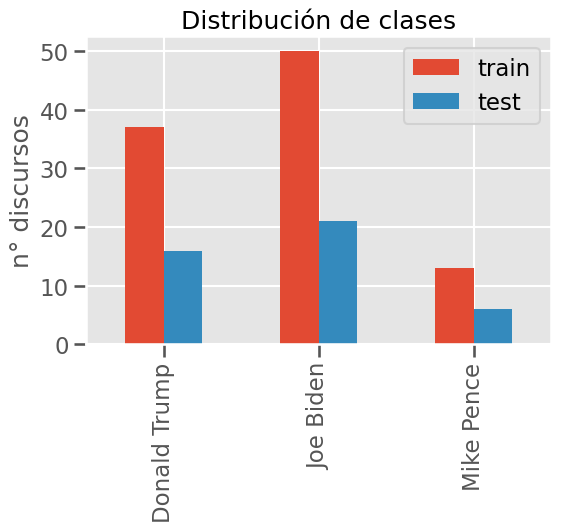


Longitud media (palabras): train=6731 ±3891, test=7393 ±4744

Discursos idénticos presentes en ambos sets: 0

✅ Split reproducible con random_state=1492


In [ ]:
# --- 0. Helpers --------------------------------------------------------------
from collections import Counter
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def describe_split(X_train, X_test, y_train, y_test):
    """Imprime y grafica diagnósticos básicos del split."""
    # 1) Conteos absolutos y relativos
    train_counts = Counter(y_train)
    test_counts  = Counter(y_test)

    df_counts = (pd.DataFrame([train_counts, test_counts],
                              index=["train","test"])
                 .T.sort_index())
    df_props = (df_counts.div(df_counts.sum(), axis=1)*100).round(1)

    print("Conteos por clase:\n", df_counts)
    print("\nProporciones (%):\n", df_props)

    # 2) Gráfico de barras lado a lado
    ax = df_counts.plot(kind="bar", figsize=(6,4))
    ax.set_ylabel("n° discursos"); ax.set_title("Distribución de clases")
    plt.show()

    # 3) Longitud media
    len_train = X_train.str.split().str.len()
    len_test  = X_test.str.split().str.len()
    print(f"\nLongitud media (palabras): train={len_train.mean():.0f} ±{len_train.std():.0f}, "
          f"test={len_test.mean():.0f} ±{len_test.std():.0f}")

    # 4) Duplicados exactos
    overlap = set(X_train).intersection(set(X_test))
    print(f"\nDiscursos idénticos presentes en ambos sets: {len(overlap)}")

# --- 1. Volver a generar el split (si hiciera falta) -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    df_top['text_clean'],
    df_top['speaker'],
    test_size=0.30,
    stratify=df_top['speaker'],
    random_state=1492
)

# 2. Ejecución del reporte ----------------------------------------------------
describe_split(X_train, X_test, y_train, y_test)

# 3. Reproducibilidad rápida --------------------------------------------------
X_train2, _, _, _ = train_test_split(
    df_top['text_clean'],
    df_top['speaker'],
    test_size=0.30,
    stratify=df_top['speaker'],
    random_state=1492
)
assert X_train.equals(X_train2), "¡El split no es reproducible!"
print("\n✅ Split reproducible con random_state=1492")


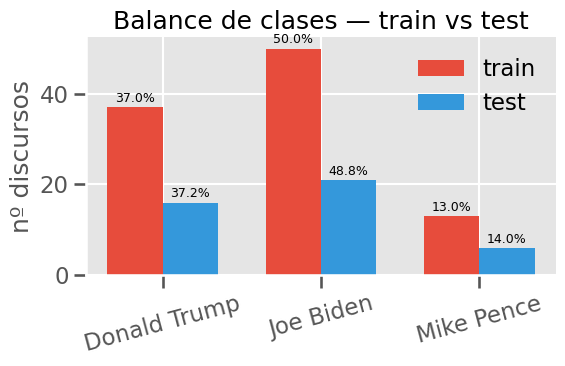

Chi² = 0.029 | p-value = 0.9855
No hay diferencia significativa: balance correcto.



In [ ]:
# ── Limpiar catálogo de categorías (si dtype='category') ─────────────
def drop_unused(series):
    return series.cat.remove_unused_categories() if hasattr(series, "cat") else series

y_train_c = drop_unused(y_train)
y_test_c  = drop_unused(y_test)

# ── Conteos absolutos (solo clases presentes) ───────────────────────
freq_train = y_train_c.value_counts(sort=False)   # observed ya no hace falta
freq_test  = y_test_c.value_counts(sort=False)

df_counts = pd.DataFrame({'train': freq_train, 'test': freq_test})

# ── Proporciones (%) ────────────────────────────────────────────────
df_props = (df_counts
            .div(df_counts.sum(axis=0), axis=1)
            .mul(100).round(1))

# ── Plot ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(6,4))
bar_w = 0.35
idx = range(len(df_counts))

ax.bar([i - bar_w/2 for i in idx], df_counts['train'],
       width=bar_w, label='train', color='#e74c3c')
ax.bar([i + bar_w/2 for i in idx], df_counts['test'],
       width=bar_w, label='test',  color='#3498db')

for i, cand in enumerate(df_counts.index):
    ax.text(i - bar_w/2, df_counts.loc[cand,'train'] + 0.5,
            f"{df_props.loc[cand,'train']}%", ha='center', va='bottom', fontsize=9)
    ax.text(i + bar_w/2, df_counts.loc[cand,'test'] + 0.5,
            f"{df_props.loc[cand,'test']}%", ha='center', va='bottom', fontsize=9)

ax.set_xticks(idx)
ax.set_xticklabels(df_counts.index, rotation=15)
ax.set_ylabel("nº discursos")
ax.set_title("Balance de clases — train vs test")
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

# ── Test χ² de homogeneidad ─────────────────────────────────────────
from scipy.stats import chi2_contingency
chi2, p, dof, _ = chi2_contingency(df_counts.T)
print(f"Chi² = {chi2:.3f} | p-value = {p:.4f}")
if p > 0.05:
    print("No hay diferencia significativa: balance correcto.\n")
else:
    print("⚠️  Posible desbalance: revisar.\n")


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
from itertools import product

# ---------- 1) Diferencias absolutas de proporciones -----------------
props_train = freq_train / freq_train.sum()
props_test  = freq_test  / freq_test.sum()
abs_diff = (props_train - props_test).abs().mul(100).round(2)

print("Diferencia absoluta de proporciones (%):")
print(abs_diff.to_string(), "\n")
print(f"Máx diferencia = {abs_diff.max():.2f}%")

# ---------- 2) Cramér’s V -------------------------------------------
chi2, p, dof, _ = chi2_contingency(df_counts.T)
n = df_counts.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(df_counts.shape) - 1)))
print(f"\nCramér's V = {cramers_v:.4f}  (0 = sin diferencia, 1 = diferencia total)")

# ---------- 3) Crosstab normalizado ---------------------------------
df_long = (pd.concat([X_train.rename('text')
                              .to_frame()
                              .assign(split='train', speaker=y_train_c),
                      X_test.rename('text')
                              .to_frame()
                              .assign(split='test',  speaker=y_test_c)]))

xtab = pd.crosstab(df_long['speaker'], df_long['split'],
                   normalize='columns') \
         .mul(100).round(1)

print("\nProporciones columna-normalizadas (%):\n", xtab)


Diferencia absoluta de proporciones (%):
speaker
Donald Trump    0.21
Joe Biden       1.16
Mike Pence      0.95 

Máx diferencia = 1.16%

Cramér's V = 0.0143  (0 = sin diferencia, 1 = diferencia total)

Proporciones columna-normalizadas (%):
 split         test  train
speaker                  
Donald Trump  37.2   37.0
Joe Biden     48.8   50.0
Mike Pence    14.0   13.0


In [ ]:
# 3: Transforme el texto del conjunto de entrenamiento a la representación numérica (features) de conteo de palabras o bag of words.
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
import pandas as pd

# -----------------------------------------------------------
# 1) Vectorizador configurado
vectorizer = CountVectorizer(
    lowercase=False,
    stop_words='english',
    min_df=2,
    max_df=0.9,                       # descarta palabras en >90 % de docs
    token_pattern=r'\b[a-z]{2,}\b'    # solo tokens alfabéticos de ≥2 letras
)

X_train_bow = vectorizer.fit_transform(X_train)
X_test_bow  = vectorizer.transform(X_test)

n_docs, n_feats = X_train_bow.shape
density = X_train_bow.nnz / (n_docs * n_feats)

print(f"Docs: {n_docs} | Vocab size: {n_feats}")
print(f"Sparsity: {density*100:.4f}%")


# 4) Ejemplo ilustrativo: vector de la 1.ª fila
first_doc = X_train.iloc[0][:120] + " [...]"  # preview
first_vec = pd.DataFrame(
    X_train_bow[0].T.todense(),
    index=vectorizer.get_feature_names_out(),
    columns=['freq']
).sort_values('freq', ascending=False).head(10)

print("Doc preview:\n", first_doc)
print("\nTop-10 términos en la 1ª fila:\n", first_vec)

Docs: 100 | Vocab size: 7783
Sparsity: 11.7829%
Doc preview:
 folks welcome to the queen theater i m here today to talk about a crisis a crisis being felt all across the united state [...]

Top-10 términos en la 1ª fila:
           freq
able        21
speaker     20
schools     18
open        16
school      15
sure        15
safely      14
need        14
help        12
children    12


X_train_bow: shape=(100, 7783), nnz=91706, density=11.7829%, memory_dense=6.2 MB, memory_sparse≈1.10 MB


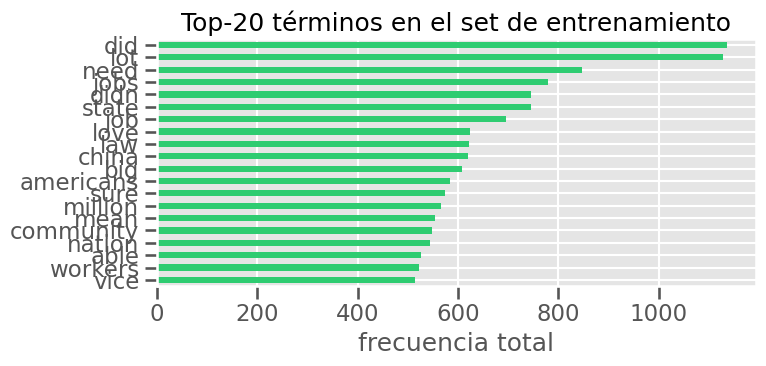

In [ ]:
from sys import getsizeof

def diagnostic(matrix, name="X"):
    n_docs, n_feat = matrix.shape
    density = matrix.nnz / (n_docs * n_feat)
    print(f"{name}: shape={matrix.shape}, nnz={matrix.nnz}, "
          f"density={density:.4%}, memory_dense={n_docs*n_feat*8/1e6:.1f} MB, "
          f"memory_sparse≈{(matrix.data.nbytes + matrix.indptr.nbytes + matrix.indices.nbytes)/1e6:.2f} MB")

diagnostic(X_train_bow, "X_train_bow")

import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Conteo global en train
total_counts = Counter()
for row in X_train_bow:
    total_counts.update(dict(zip(vectorizer.get_feature_names_out(), row.toarray()[0])))

top20 = pd.Series(dict(total_counts)).sort_values(ascending=False).head(20)

plt.figure(figsize=(8,4))
top20[::-1].plot(kind='barh', color='#2ecc71')
plt.title('Top-20 términos en el set de entrenamiento')
plt.xlabel('frecuencia total')
plt.tight_layout()
plt.show()


Docs: 100 | Vocab (1+2-gramas): 37374
Sparsity real: 94.6% ceros (densidad 5.35%)

Top-10 términos/2-gramas por TF-IDF en el 1.er discurso:
educators             0.068
kenosha               0.067
children need         0.062
curious               0.062
schools safely        0.059
kenosha wisconsin     0.058
safely effectively    0.058
reopen schools        0.055
childcare             0.054
going school          0.053
dtype: float64
dense ≈ 29.9 MB  |  sparse ≈ 2.40 MB  (12.5× ahorro)
Bigramas: 29,594  |  Unigramas: 7,780


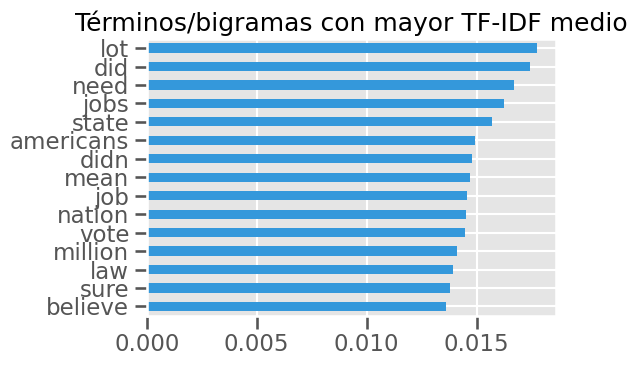

In [ ]:
# 4: Obtenga la representación numérica Term Frequency - Inverse Document Frequency.

from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np

# ---------------- Configuración crítica ----------------
tfidf_vec = make_tfidf()

# ----- Fit SOLO con train (previene data-leakage)
X_train_tfidf = tfidf_vec.fit_transform(X_train)
X_test_tfidf  = tfidf_vec.transform(X_test)

# ----- Diagnóstico rápido
n_docs, n_feats = X_train_tfidf.shape
density = X_train_tfidf.nnz / (n_docs * n_feats)

print(f"Docs: {n_docs} | Vocab (1+2-gramas): {n_feats}")
print(f"Sparsity real: {100 - density*100:.1f}% ceros "
      f"(densidad {density*100:.2f}%)")

# ----- Ejemplo: top términos (según TF-IDF) del 1.er discurso
feature_names = np.array(tfidf_vec.get_feature_names_out())
row = X_train_tfidf[0].tocoo()
top_idx = row.data.argsort()[::-1][:10]
top_terms = pd.Series(row.data[top_idx], index=feature_names[row.col[top_idx]])

print("\nTop-10 términos/2-gramas por TF-IDF en el 1.er discurso:")
print(top_terms.round(3))

def mem_report(mat):
    dense_mb = mat.shape[0]*mat.shape[1]*8/1e6
    sparse_mb = (mat.data.nbytes+mat.indptr.nbytes+mat.indices.nbytes)/1e6
    print(f"dense ≈ {dense_mb:.1f} MB  |  sparse ≈ {sparse_mb:.2f} MB  "
          f"({dense_mb/sparse_mb:.1f}× ahorro)")
mem_report(X_train_tfidf)

feat_names = tfidf_vec.get_feature_names_out()
n_bigrams = sum(1 for f in feat_names if " " in f)
print(f"Bigramas: {n_bigrams:,}  |  Unigramas: {len(feat_names)-n_bigrams:,}")

import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
# Media TF-IDF por término en todo el train
mean_tfidf = np.asarray(X_train_tfidf.mean(axis=0)).ravel()
df_tfidf = pd.Series(mean_tfidf, index=feat_names)
(df_tfidf.sort_values(ascending=False)
         .head(15)
         .sort_values()
         .plot(kind='barh', figsize=(6,4), color='#3498db'))
plt.title('Términos/bigramas con mayor TF-IDF medio')
plt.tight_layout()
plt.show()



In [ ]:
print("¿Persisten nombres en text_clean?",
      df_top["text_clean"].str.contains(r"\b(joe|biden|donald|trump|mike|pence)\b", case=False).any())

any("biden" in txt for txt in X_train.head())

offenders = [txt for txt in X_train.head(20) if "biden" in txt.lower()]
print("\n".join(offenders[:5]))

# ¿quedan tokens con nombres propios en el vocabulario?
bad = [w for w in tfidf_vec.get_feature_names_out() if w.split()[0] in EXTRA_NAMES]
print("Nombres en vocabulario:", bad[:15])        # debería salir []
assert not bad, "Aún quedan nombres en el vocabulario"

# ¿quedan en el texto?
assert not df_top["text_clean"].str.contains(NAME_PATTERN).any(), "Aún quedan nombres en el texto"


¿Persisten nombres en text_clean? False

Nombres en vocabulario: []


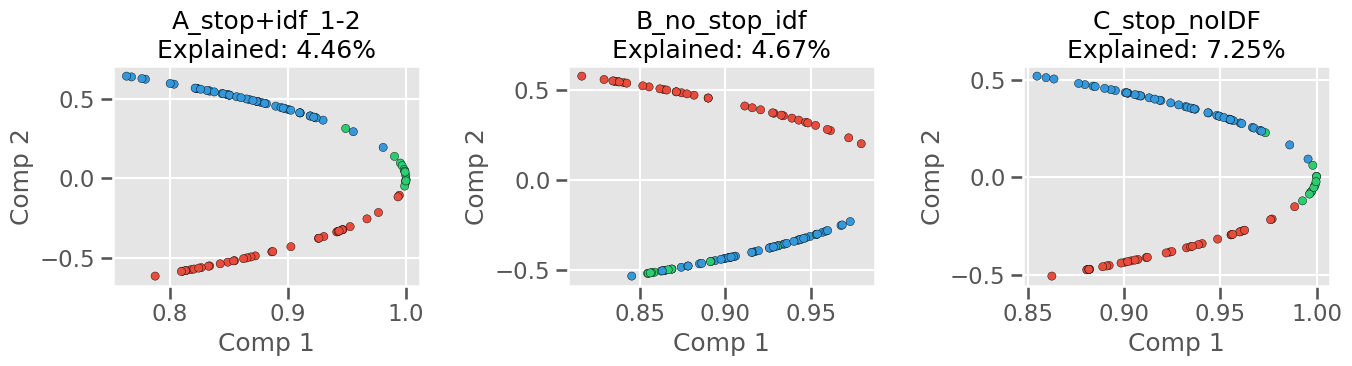

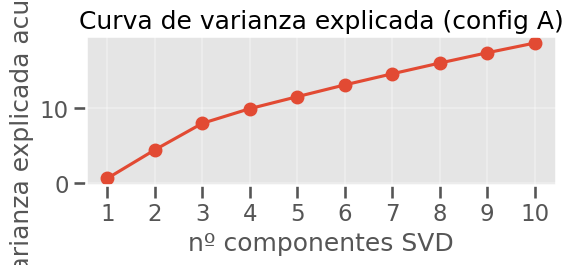


Top-10 términos — Componente 1
lot          0.050978
did          0.050743
need         0.047547
jobs         0.047279
state        0.046780
didn         0.043888
job          0.043321
americans    0.043237
nation       0.042337
mean         0.042251
dtype: float64

Top-10 términos — Componente 2
crisis         0.063733
covid          0.053017
fake           0.047879
folks          0.045365
act            0.045168
make sure      0.042745
usa usa        0.042457
making sure    0.042054
sleepy         0.041648
usa            0.041507
dtype: float64


In [ ]:
# 5 ── Mapa 2-D con SVD (≃PCA) sobre TF-IDF ------------------------------
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition  import TruncatedSVD
from sklearn.pipeline       import make_pipeline
from sklearn.preprocessing  import Normalizer
import matplotlib.pyplot as plt
import seaborn as sns, numpy as np, pandas as pd

def svd_map(X_text, y, *,
            stop_words=build_stopwords(),
            extra_stop=None,
            use_idf=True,
            ngram_range=(1, 2),
            remove_punct=True,
            n_components=2,
            random_state=42):
    """Devuelve proyección 2-D, varianza explicada y pipeline entrenado."""
    # ----- stop-words compuestas ---------------------------------------
    if extra_stop:
        if stop_words is None:
            stop_words = extra_stop
        else:
            stop_words = set(sns.text.get_stopwords(stop_words)).union(extra_stop)

    token_pat = r'\b[a-z]{2,}\b' if remove_punct else r'\b\w+\b'
    vect = TfidfVectorizer(lowercase=False, stop_words=stop_words,
                           token_pattern=token_pat,
                           ngram_range=ngram_range,
                           min_df=2, max_df=0.9,
                           sublinear_tf=True, norm='l2',
                           use_idf=use_idf)

    svd   = TruncatedSVD(n_components=n_components, random_state=random_state)
    pipe  = make_pipeline(vect, svd, Normalizer(copy=False))
    X_proj = pipe.fit_transform(X_text)

    return X_proj, svd.explained_variance_ratio_, pipe


# ── Configuraciones a comparar -----------------------------------------------
configs = {
    'A_stop+idf_1-2': {},  # usa build_stopwords() por defecto
    'B_no_stop_idf'  : {'stop_words': None},
    'C_stop_noIDF'   : {'use_idf': False},
}

proj, var_ratio = {}, {}
for label, params in configs.items():
    proj[label], var_ratio[label], _ = svd_map(X_train, y_train_c, **params)

# ── Scatter plots ------------------------------------------------------------
palette = {'Donald Trump':'#e74c3c', 'Joe Biden':'#3498db', 'Mike Pence':'#2ecc71'}
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (lbl, Xp) in zip(axes, proj.items()):
    sns.scatterplot(x=Xp[:, 0], y=Xp[:, 1], hue=y_train_c,
                    palette=palette, s=35, ax=ax, linewidth=0.3, edgecolor='k')
    ax.set_title(f"{lbl}\nExplained: {var_ratio[lbl][:2].sum():.2%}")
    ax.set_xlabel('Comp 1'); ax.set_ylabel('Comp 2')
    ax.legend([], [], frameon=False)
plt.tight_layout(); plt.show()

# ── Curva de varianza acumulada (config A) -----------------------------------
_, var_full, pipeA = svd_map(X_train, y_train_c, n_components=10, **configs['A_stop+idf_1-2'])
plt.figure(figsize=(6, 3))
plt.plot(range(1, 11), np.cumsum(var_full)*100, marker='o')
plt.xticks(range(1, 11)); plt.ylabel('% varianza explicada acumulada')
plt.xlabel('nº componentes SVD'); plt.grid(alpha=.3)
plt.title('Curva de varianza explicada (config A)')
plt.tight_layout(); plt.show()

# ── Top-10 términos por componente 1-2 ---------------------------------------
vect = pipeA.named_steps['tfidfvectorizer']
svd  = pipeA.named_steps['truncatedsvd']
terms = np.array(vect.get_feature_names_out())

for idx in (0, 1):
    comp = pd.Series(svd.components_[idx], index=terms).abs().nlargest(10)
    print(f"\nTop-10 términos — Componente {idx+1}")
    print(comp)


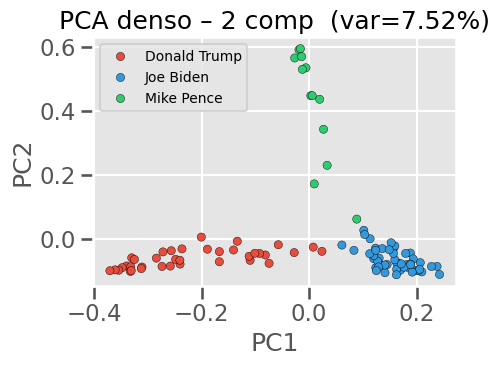

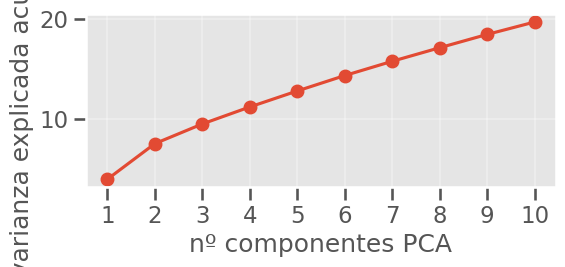


Top-10 términos — Componente 1
crisis         0.05538
crazy         -0.04341
fake news     -0.04347
years years   -0.04441
great job     -0.04495
sleepy        -0.04573
usa           -0.04646
usa usa       -0.04654
china         -0.04806
fake          -0.05189
dtype: float64

Top-10 términos — Componente 2
red tape           0.05463
stood              0.05408
liberties          0.05404
men women          0.05396
freedom            0.05277
years means        0.05097
faith              0.04955
pray               0.04898
challenging        0.04801
choice election    0.04785
dtype: float64


In [ ]:
# PCA Puro

from sklearn.decomposition import PCA
from sklearn.preprocessing  import StandardScaler  # opcional

tfidf_vec = tfidf_vec = make_tfidf()
X_train_tfidf = tfidf_vec.fit_transform(X_train).toarray()   # densificar

# (opcional) centrar + escalar fila a fila
X_train_tfidf = StandardScaler(with_std=False).fit_transform(X_train_tfidf)

pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_train_tfidf)

# scatter 2-D
plt.figure(figsize=(5,4))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y_train_c,
                palette=palette, s=35, linewidth=.3, edgecolor='k')
plt.title(f"PCA denso – 2 comp  (var={pca.explained_variance_ratio_[:2].sum():.2%})")
plt.xlabel('PC1'); plt.ylabel('PC2');
plt.legend(fontsize=10)
plt.tight_layout(); plt.show()


# curva de varianza
plt.figure(figsize=(6,3))
plt.plot(range(1,11), np.cumsum(pca.explained_variance_ratio_[:10])*100, marker='o')
plt.xticks(range(1,11)); plt.ylabel('% varianza explicada acumulada')
plt.xlabel('nº componentes PCA'); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

# ── Top-10 términos por componente 1 y 2 (PCA denso) ────────────────────────
# (Suponemos que tfidf_vec y X_train_tfidf ya están definidos)

feature_names = np.array(tfidf_vec.get_feature_names_out())   # vocabulario

for idx in (0, 1):
    # pesos de la componente idx
    comp_weights = pca.components_[idx]

    # selección de los 10 términos con |peso| más alto
    top_idx = np.abs(comp_weights).argsort()[::-1][:10]
    top_terms = pd.Series(comp_weights[top_idx], index=feature_names[top_idx])

    print(f"\nTop-10 términos — Componente {idx+1}")
    print(top_terms.round(5).sort_values(ascending=False))



## Parte 2: Entrenamiento y Evaluación de Modelos


Accuracy  : 0.930

Donald Trump   precision=1.000  recall=0.875
Joe Biden      precision=0.875  recall=1.000
Mike Pence     precision=1.000  recall=0.833


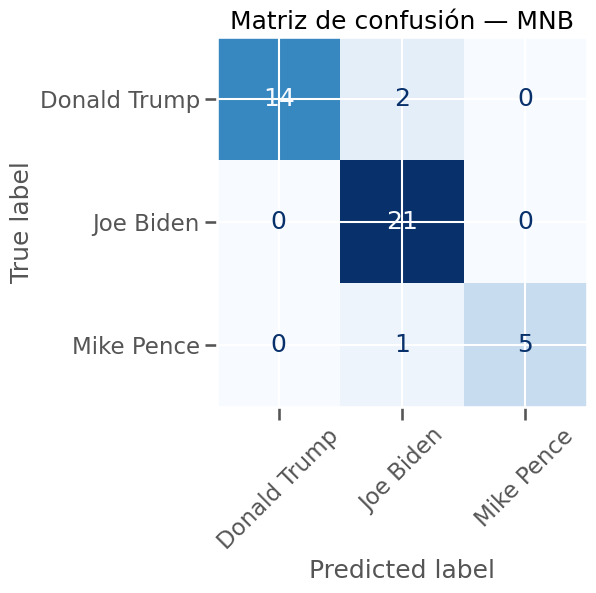

In [ ]:
# 1: Entrene el modelo Multinomial Naive Bayes, luego utilícelo para predecir sobre el conjunto de test, y reporte el valor de accuracy y la matriz de confusión. Reporte el valor de precision y recall para cada candidato.
# Calcular matriz de confusión Sugerencia: utilice el método from_predictions de ConfusionMatrixDisplay para realizar la matriz.

from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    ConfusionMatrixDisplay
)

pipe = make_mnb_pipeline(alpha=1.0)

# ── Entrenar SOLO con train ───────────────────────────────────────
pipe.fit(X_train, y_train_c)

# ── Predicciones en test ──────────────────────────────────────────
y_pred = pipe.predict(X_test)

acc = accuracy_score(y_test_c, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(
    y_test_c, y_pred, average=None, labels=y_train_c.cat.categories
)

print(f"Accuracy  : {acc:.3f}\n")

for cls, p, r in zip(y_train_c.cat.categories, prec, rec):
    print(f"{cls:<13}  precision={p:.3f}  recall={r:.3f}")


cm_disp = ConfusionMatrixDisplay.from_predictions(
    y_test_c, y_pred,
    cmap='Blues', colorbar=False,
    display_labels=y_train_c.cat.categories, xticks_rotation=45
)
cm_disp.ax_.set_title("Matriz de confusión — MNB")
#plt.tight_layout()
plt.show()


In [ ]:
# 2: Implemente una búsqueda de hiperparámetros usando GridSearchCV.

from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import StratifiedKFold, GridSearchCV
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt

# ── pipeline base ──────────────────────────────────────────────────
pipe = make_mnb_pipeline()

# ── hiperparámetros a explorar ────────────────────────────────────
param_grid = {
    'tfidfvectorizer__ngram_range': [(1,1), (1,2)],
    'tfidfvectorizer__min_df'     : [1, 2],
    'multinomialnb__alpha'        : [0.1, 1.0, 5.0]
}


# –– validación estratificada 5-fold — reproducible ────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(pipe,
                    param_grid=param_grid,
                    scoring='accuracy',
                    cv=cv,
                    n_jobs=-1,
                    return_train_score=False)

grid.fit(X_train, y_train_c)        # <-- SOLO sobre train

print("Best params :", grid.best_params_)
print("CV accuracy :", grid.best_score_.round(3))


# Genere una visualización que permita comparar las métricas (e.g: accuracy) de los distintos modelos entrenados, viendo el valor promedio y variabilidad de las mismas en todos los splits (e.g: en un gráfico de violín).

# ==== construir dataframe largo con los scores de cada split =========
import re, pandas as pd
res = pd.DataFrame(grid.cv_results_)

# -------- 1. Detectar columnas de los splits ------------------------
split_cols = [c for c in res.columns if re.match(r"split\d+_.*test_score", c)]
if not split_cols:   # fallback para versiones antiguas
    split_cols = [c for c in res.columns if c.startswith("split") and c.endswith("_test_score")]

# -------- 2. Construir etiqueta legible del combo -------------------
def format_combo(row):
    alpha  = row.get('param_multinomialnb__alpha', grid.cv_results_['param_multinomialnb__alpha'][0])
    min_df = row.get('param_tfidfvectorizer__min_df', grid.cv_results_['param_tfidfvectorizer__min_df'][0])
    ngram  = row.get('param_tfidfvectorizer__ngram_range', grid.cv_results_['param_tfidfvectorizer__ngram_range'][0])
    return f"α={alpha}\nmin_df={min_df}\nng={ngram}"

res['combo'] = res.apply(format_combo, axis=1)

# -------- 3. Pasar a formato largo (score por split) ----------------
long = (
    res[['combo'] + split_cols]
      .set_index('combo')
      .rename(columns=lambda c: re.sub(r'.*?(\d+).*', r'split\1', c))   # homogeneizar nombres
      .stack()
      .reset_index()
      .rename(columns={'level_1':'split', 0:'accuracy'})
)





Best params : {'multinomialnb__alpha': 0.1, 'tfidfvectorizer__min_df': 2, 'tfidfvectorizer__ngram_range': (1, 1)}
CV accuracy : 0.99


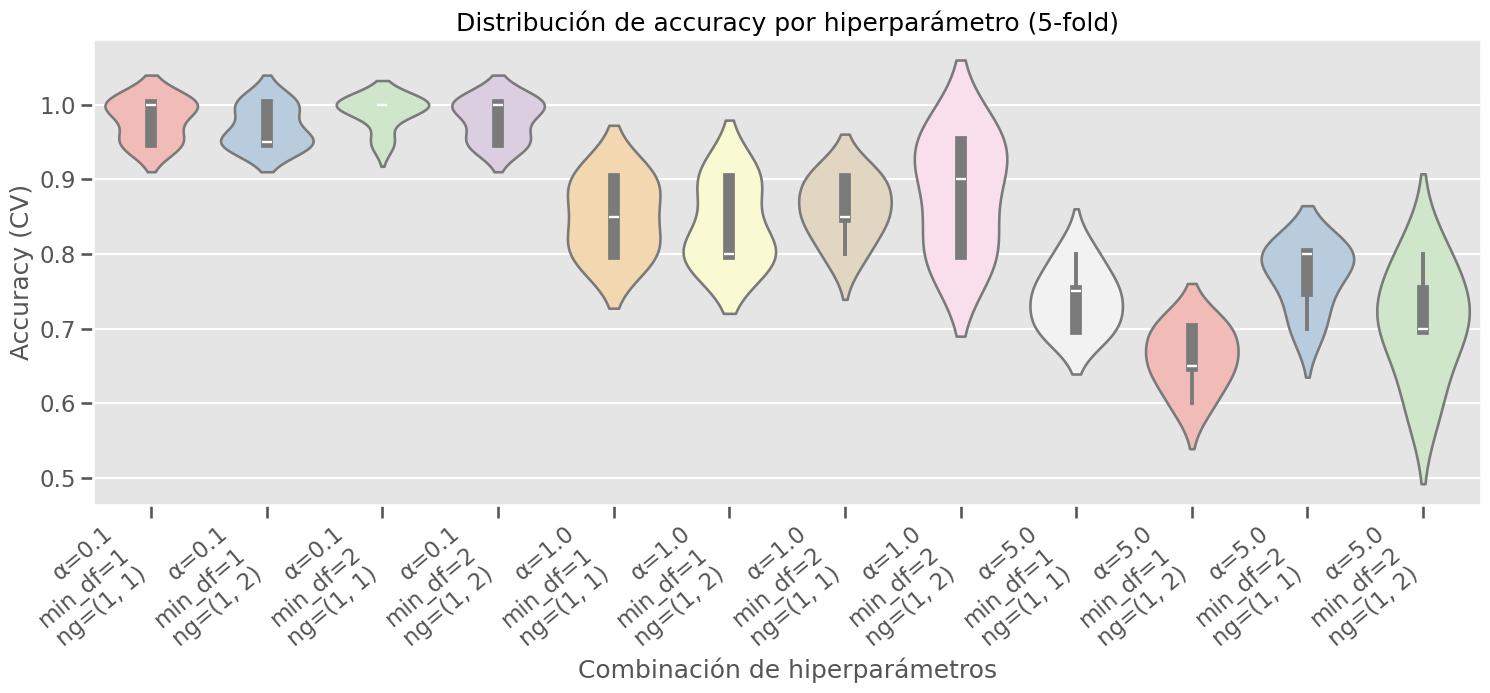

In [ ]:
# -------- 4. Gráfico de violín -------------------------------------
import seaborn as sns, matplotlib.pyplot as plt
plt.figure(figsize=(15,7))
plt.rcParams.update({'font.size': 9})
sns.violinplot(data=long, x='combo', y='accuracy', inner='box', palette='Pastel1')
#plt.axhline(0.49, ls='--', lw=1, c='red', label='baseline (mayoría)')
plt.legend(frameon=False); plt.ylabel('Accuracy (CV)')
plt.title('Distribución de accuracy por hiperparámetro (5-fold)')
plt.xticks(rotation=40, ha='right');
plt.xlabel('Combinación de hiperparámetros')
plt.tight_layout()
plt.show()

In [ ]:
# Pequeña inspección rápida
any("biden" in txt for txt in X_train.head())

False

Accuracy   : 1.000
Macro-F1   : 1.000



,precision,recall,f1,support
Donald Trump,1.000,1.000,1.000,16.000
Joe Biden,1.000,1.000,1.000,21.000
Mike Pence,1.000,1.000,1.000,6.000


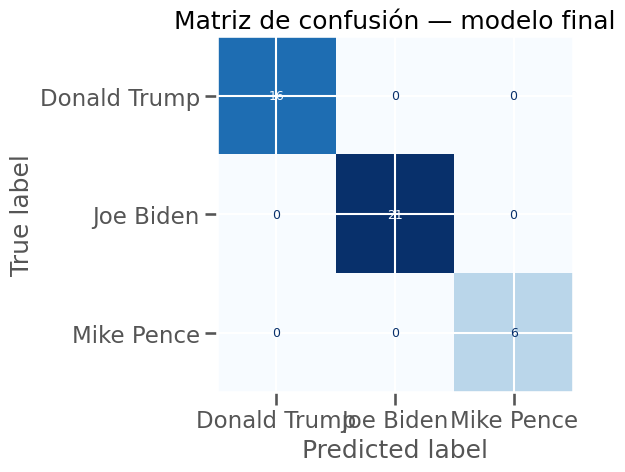

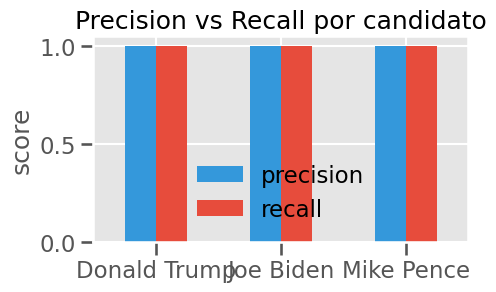

In [ ]:
# 3 ▌ Modelo definitivo ─ re-entreno en TODO el set de train
#    (usa los hiperparámetros ganadores de la búsqueda de CV)
# ------------------------------------------------------------------

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import pandas as pd

# 1 ── Pipeline con la misma fábrica que venimos usando ─────────────
#     – toma las stop-words dinámicas de build_stopwords()
#     – quita nombres o no según INCLUDE_NAMES
best_pipe = make_mnb_pipeline(
    alpha        = 0.1,      # ← ganador CV
    ngram_range  = (1, 1),   # ← ganador CV
    min_df       = 2         # ← ganador CV
)

best_pipe.fit(X_train, y_train_c)          # ENTRENAR
y_pred = best_pipe.predict(X_test)         # PREDECIR

# 2 ── Métricas ------------------------------------------------------
acc  = accuracy_score(y_test_c, y_pred)
prec, rec, f1, supp = precision_recall_fscore_support(
    y_test_c, y_pred, labels=y_train_c.cat.categories, average=None
)
macro_f1 = f1.mean()

print(f"Accuracy   : {acc:.3f}")
print(f"Macro-F1   : {macro_f1:.3f}\n")

report_df = pd.DataFrame(
    {'precision':prec,'recall':rec,'f1':f1,'support':supp},
    index=y_train_c.cat.categories
)
display(report_df.style.format("{:.3f}"))

# 3 ── Matriz de confusión ------------------------------------------
ConfusionMatrixDisplay.from_predictions(
    y_test_c, y_pred,
    display_labels=y_train_c.cat.categories,
    cmap='Blues', colorbar=False).ax_.set_title("Matriz de confusión — modelo final")
plt.tight_layout(); plt.show()

# 4 ── Precision / Recall por clase ---------------------------------
report_df[['precision','recall']].plot(
    kind='bar', figsize=(5,3), color=['#3498db','#e74c3c']
)
plt.ylim(0,1.05); plt.ylabel('score'); plt.xticks(rotation=0)
plt.title('Precision vs Recall por candidato'); plt.legend(frameon=False)
plt.tight_layout(); plt.show()


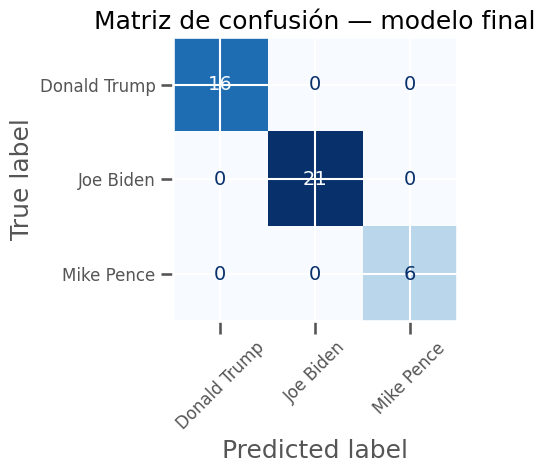

In [ ]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test_c, y_pred,
    display_labels=y_train_c.cat.categories,
    cmap='Blues',
    colorbar=False,xticks_rotation=45
)
disp.ax_.set_title("Matriz de confusión — modelo final")

# Change fontsize of numbers inside the matrix
for text in disp.ax_.texts:
    text.set_fontsize(14)  # Change 12 to your desired fontsize

# Change fontsize of axis tick labels
disp.ax_.set_xticklabels(disp.ax_.get_xticklabels(), fontsize=12)
disp.ax_.set_yticklabels(disp.ax_.get_yticklabels(), fontsize=12)

plt.tight_layout()
plt.show()


In [ ]:
# ▌ Experimentos de ablación y aleatorización ────────────
import re, random
from sklearn.base import clone
from sklearn.utils import shuffle
import numpy as np

# 1 ── enmascarar nombres propios con el MISMO patrón global ------------
mask = lambda s: NAME_PATTERN.sub("<name>", s)

best_pipe_clean = make_mnb_pipeline(alpha=0.1, ngram_range=(1,1), min_df=2)  # clon limpio
best_pipe_clean.fit(X_train.apply(mask), y_train_c)
print("Accuracy sin nombres propios:",
      accuracy_score(y_test_c, best_pipe_clean.predict(X_test.apply(mask))))

# ---- tokens con mayor probabilidad por clase --------------------------
def show_top_tokens(pipe, k=15):
    vect = pipe.named_steps['tfidfvectorizer']
    clf  = pipe.named_steps['multinomialnb']
    terms = np.array(vect.get_feature_names_out())
    for idx, cls in enumerate(clf.classes_):
        top = terms[np.argsort(clf.feature_log_prob_[idx])[::-1][:k]]
        print(f"\nClase {cls} — top {k}:")
        print(", ".join(top))

show_top_tokens(best_pipe_clean)

# 2 ── etiquetas permutadas (baseline random) ---------------------------
pipe_perm = clone(best_pipe_clean)
acc_perm = pipe_perm.fit(X_train, shuffle(y_train_c, random_state=0)).score(X_test, y_test_c)
print("Accuracy con labels permutadas:", round(acc_perm, 3))

# 3 ── palabras desordenadas en cada discurso ---------------------------
def shuffle_words(text):
    words = text.split()
    random.Random(0).shuffle(words)
    return " ".join(words)

acc_shuff = best_pipe_clean.score(X_test.apply(shuffle_words), y_test_c)
print("Accuracy con palabras barajadas:", round(acc_shuff, 3))

# 4 ── enmascarar nombres + títulos -------------------------------------
regex_names_titles = re.compile(
    r"\b("
    r"donald|trump|joe|biden|mike|pence|"
    r"president(?:s)?|vice(?:-president)?|senator(?:s)?)\b",
    flags=re.I
)
mask_all = lambda s: regex_names_titles.sub("<mask>", s)

pipe_all = make_mnb_pipeline(alpha=0.1, ngram_range=(1,1), min_df=2)
pipe_all.fit(X_train.apply(mask_all), y_train_c)
print("Accuracy sin nombres ni títulos:",
      round(pipe_all.score(X_test.apply(mask_all), y_test_c), 3))


Accuracy sin nombres propios: 1.0

Clase Donald Trump — top 15:
lot, china, did, fake, win, big, love, ballots, crazy, horrible, guy, nice, incredible, everybody, okay

Clase Joe Biden — top 15:
crisis, need, folks, covid, sure, act, able, workers, lot, health, making, public, plan, build, families

Clase Mike Pence — top 15:
enforcement, faith, freedom, stood, pray, liberties, law, challenging, men, principled, blue, coronavirus, choice, uniform, abortion
Accuracy con labels permutadas: 0.395
Accuracy con palabras barajadas: 1.0
Accuracy sin nombres ni títulos: 1.0


Accuracy LR: 1.000


,precision,recall,f1
Donald Trump,1.000,1.000,1.000
Joe Biden,1.000,1.000,1.000
Mike Pence,1.000,1.000,1.000


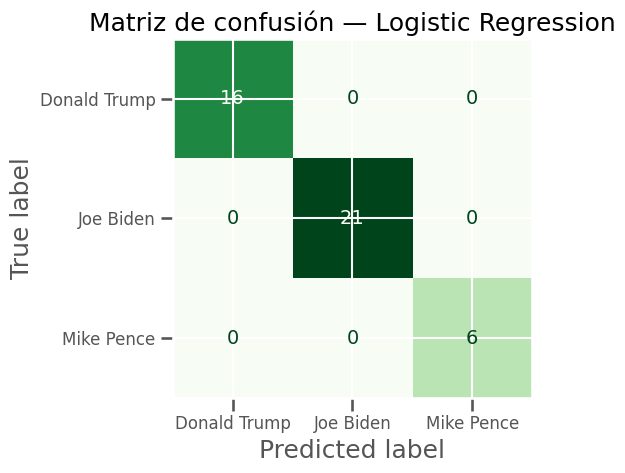

In [ ]:
# ▌ Logistic Regression con el vectorizador coherente
# ---------------------------------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,
                             precision_recall_fscore_support,
                             ConfusionMatrixDisplay)
from sklearn.base import clone
import matplotlib.pyplot as plt
import pandas as pd

# 1 ── pipeline: utiliza make_tfidf (respeta INCLUDE_NAMES) ──────────
pipe_lr = make_pipeline(
    make_tfidf(ngram_range=(1,1), min_df=2, use_idf=True),
    LogisticRegression(
        penalty='l2', C=1.0, max_iter=2000,
        solver='saga', n_jobs=-1, multi_class='multinomial'
    )
)

pipe_lr.fit(X_train, y_train_c)
y_pred_lr = pipe_lr.predict(X_test)

# 2 ── métricas -------------------------------------------------------
acc_lr  = accuracy_score(y_test_c, y_pred_lr)
prec_lr, rec_lr, f1_lr, _ = precision_recall_fscore_support(
    y_test_c, y_pred_lr, labels=y_train_c.cat.categories, average=None
)

print(f"Accuracy LR: {acc_lr:.3f}")

metrics_lr = pd.DataFrame(
    {'precision':prec_lr, 'recall':rec_lr, 'f1':f1_lr},
    index=y_train_c.cat.categories
)
display(metrics_lr.style.format("{:.3f}"))

# 3 ── matriz de confusión -------------------------------------------
disp = ConfusionMatrixDisplay.from_predictions(
    y_test_c, y_pred_lr,
    display_labels=y_train_c.cat.categories,
    cmap='Greens', colorbar=False
)
disp.ax_.set_title("Matriz de confusión — modelo final", fontsize=10)

# Change fontsize of numbers inside the matrix
for text in disp.ax_.texts:
    text.set_fontsize(14)  # Change 12 to your desired fontsize

# Change fontsize of axis tick labels
disp.ax_.set_xticklabels(disp.ax_.get_xticklabels(), fontsize=12)
disp.ax_.set_yticklabels(disp.ax_.get_yticklabels(), fontsize=12)

plt.title("Matriz de confusión — Logistic Regression")
plt.tight_layout(); plt.show()


In [ ]:
# ▌ PARTE 2 · 5 ─ Cambio de candidato: Kamala Harris
# ---------------------------------------------------
import re, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             ConfusionMatrixDisplay)

NEW_CLASSES = ['Donald Trump', 'Joe Biden', 'Kamala Harris']

# 1 ── Sub-dataset y limpieza coherente ───────────────────────────────
df_sub = df[df['speaker'].isin(NEW_CLASSES)].copy()

# usa la MISMA función clean_text que en todo el notebook
df_sub['text_clean'] = clean_text(df_sub['text'])

# verifica tamaño por clase (puede haber pocos discursos de Harris)
print(df_sub['speaker'].value_counts(dropna=False))

X_tr, X_te, y_tr, y_te = train_test_split(
    df_sub['text_clean'], df_sub['speaker'],
    test_size = .30,
    stratify  = df_sub['speaker'],
    random_state = 42
)

# 2 ── Pipeline: vectorizador global + MNB ────────────────────────────
pipe_h3 = make_mnb_pipeline(        # ← respeta INCLUDE_NAMES
    alpha       = 0.1,
    ngram_range = (1,1),
    min_df      = 1                 # con Harris hay menos docs → min_df=1
)

pipe_h3.fit(X_tr, y_tr)
y_pred = pipe_h3.predict(X_te)

# 3 ── Métricas & visualización ───────────────────────────────────────
acc  = accuracy_score(y_te, y_pred)
prec, rec, f1, supp = precision_recall_fscore_support(
    y_te, y_pred, labels = pipe_h3.classes_, zero_division = 0
)

metrics = pd.DataFrame(
    {'precision':prec, 'recall':rec, 'f1':f1, 'support':supp},
    index = pipe_h3.classes_
).round(3)

print(f"\nAccuracy global: {acc:.3f}\n")
display(metrics)

speaker
Joe Biden        71
Donald Trump     53
Kamala Harris    11
Andrew Cuomo      0
???               0
                 ..
Tiffany Trump     0
Tim Scott         0
Tom Cotton        0
Tulsi Gabbard     0
Val Demings       0
Name: count, Length: 71, dtype: int64

Accuracy global: 0.927



,precision,recall,f1,support
Donald Trump,1.00,1.0,1.000,16
Joe Biden,0.88,1.0,0.936,22
Kamala Harris,0.00,0.0,0.000,3


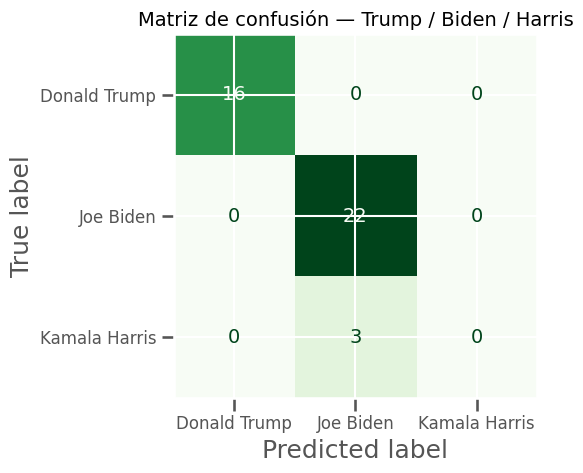

In [ ]:

disp = ConfusionMatrixDisplay.from_predictions(
    y_te, y_pred, display_labels = pipe_h3.classes_,
    cmap = 'Greens', colorbar = False
)
disp.ax_.set_title("Matriz de confusión — Trump / Biden / Harris", fontsize=14)

# Change fontsize of numbers inside the matrix
for text in disp.ax_.texts:
    text.set_fontsize(14)  # Change 12 to your desired fontsize

# Change fontsize of axis tick labels
disp.ax_.set_xticklabels(disp.ax_.get_xticklabels(), fontsize=12)
disp.ax_.set_yticklabels(disp.ax_.get_yticklabels(), fontsize=12)

plt.tight_layout(); plt.show()

In [ ]:
# OPCIONAL: Repetir la clasificación con los tres candidatos con más discursos, pero esta vez clasificando a nivel de párrafos y no de discursos enteros.
